In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
dataset_dir = Path("../../data_generation/dataset_01_20260223")
metadata_path = dataset_dir / "metadata.json"
datafile_number = 0
datafile_path = dataset_dir / f"images_{datafile_number}.npy"
parameters_path = dataset_dir / f"params_{datafile_number}.npy"

metadata = json.load(metadata_path.open())
data = np.load(datafile_path, mmap_mode="r") # do not load to RAM, but read from disk when needed
parameters = np.load(parameters_path)


In [3]:
print(f"Data shape: {data.shape}")
print(f"Parameters shape: {parameters.shape}")

print("Metadata:")
print(json.dumps(metadata, indent=4))

Data shape: (100000, 296, 296)
Parameters shape: (100000, 5)
Metadata:
{
    "n_images_per_file": 100000,
    "nm_per_pixel": 2.0,
    "n_files": 10,
    "image_size_px": 296,
    "params_list": [
        "uc_scale_ab",
        "channel_vol_prop",
        "h",
        "k",
        "l"
    ],
    "fixed_paramters": {
        "W": 296,
        "structure_type": 1,
        "slice_height": 593.9696961966999,
        "slice_width": 593.9696961966999,
        "slice_thickness": 70.0,
        "slice_position": 0.0,
        "membrane_distance": 0.0,
        "membrane_thickness": 5.0,
        "image_depth": 75
    },
    "max_consecutive_generation_failures": 200
}


Parameters for image 10:
uc_scale_ab: 75.20
channel_vol_prop: 0.27
h: 58.00
k: 44.00
l: -36.00


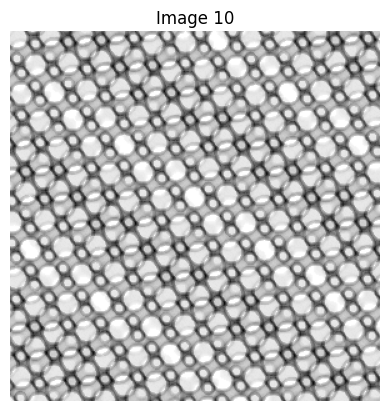

In [12]:
idx = 10
image = data[idx]
image_params = parameters[idx]

fig, ax = plt.subplots()
ax.imshow(image, cmap="gray")
ax.set_axis_off()
ax.set_title(f"Image {idx}")
print(f"Parameters for image {idx}:")
for param_name, param_value in zip(metadata["params_list"], image_params):
    print(f"{param_name}: {param_value:.2f}")